**Lab 4: Data processing**
In this lab, we will try to do some statistical analysis to draw conclusions from the collected data. The purpose of this lab is to introduce you to the proper way of analyzing the data to be able to claim the relationship between variables. We will use the data from an open-access research dataset online:

Mongin, D., García Romero, J., & Alvero Cruz, J. R. (2021). Treadmill Maximal Exercise Tests from the Exercise Physiology and Human Performance Lab of the University of Malaga (version 1.0.1). PhysioNet. RRID:SCR_007345. https://doi.org/10.13026/7ezk-j442

Please click the DOI link and read through the page, especially the **"Data Description"** section.

In [1]:
# Scientific packages
import numpy as np
import pandas

import scipy
import matplotlib.pyplot as plt

In [2]:
user_data =  pandas.read_csv('subject-info.csv')
test_data = pandas.read_csv('test_measure.csv')

**Step 1:** load the data and calculate the metabolic rate for each user

For this step, you would need to do some quick research on how metabolic rate could be measured through oxygen consumption (VO2) and carbon dioxide generation (VCO2). Please properly cite your reference and make sure it is an academic publication instead of a random webpage. Then, use the formula you found the calculate the metabolic rate for each of the users in the dataset. **Keep in mind that you may need to convert the units before doing the math!!**

In [3]:
unique_tests = test_data['ID_test'].unique()

user_MR = np.zeros((len(unique_tests), 2))
counter = 0

for i in unique_tests:
    single_test = test_data[test_data['ID_test'] == i]

    # from https://doi.org/10.1113/jphysiol.1949.sp004363
    vo2 = single_test['VO2'].values[0] # ml/min
    vco2 = single_test['VCO2'].values[0] # ml/min
    metabolic_rate = 1440 * (3.9 * vo2 / 1000 + 1.1 * vco2 / 1000) # kcal/day

    user_ID = single_test['ID'].values[0]
    user_MR[counter, 0] = user_ID
    user_MR[counter, 1] = metabolic_rate
    counter += 1


Now we start doing statistics:

**Step 2:** Choose two parameters to compare the metabolic rate with, one continuous and one categorical

Example for continuous parameter could be age, height, weight

Example for the categorical parametr could be sex, arbitrary categories of age (under 18 vs 18~49 vs 50 and above)

**Step 3:** For continuous parameter, run correlation to show its relationship to the metabolic rate, and fit a regression line if possible

**Step 4:** For categorical parameter, run a t-test to show whether it has a significant impact on the metabolic rate

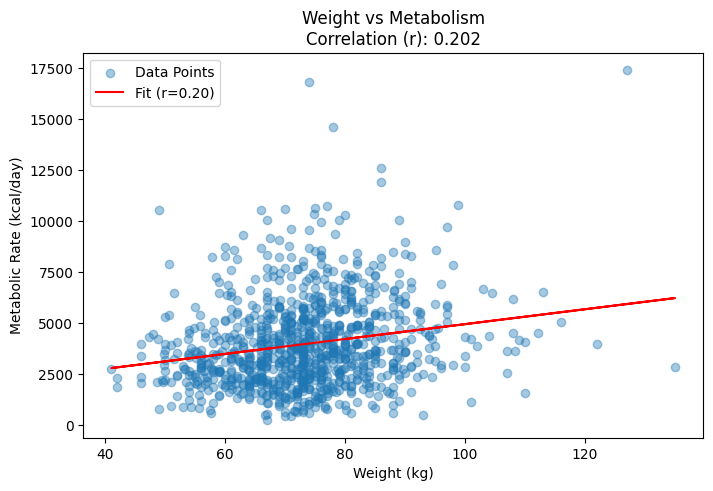

In [4]:
## Continuous variable
x = []
y = []
for user_ID, rate in user_MR:
    weight = user_data[user_data['ID'] == user_ID]['Weight'].values[0]
    x.append(weight)
    y.append(rate)

# fit regression line
from scipy import stats
x_arr = np.array(x, dtype=float)
y_arr = np.array(y, dtype=float)

mask = ~np.isnan(y_arr)
x_final = x_arr[mask]
y_final = y_arr[mask]

slope, intercept = np.polyfit(x_final, y_final, 1)
r_val, p_val = stats.pearsonr(x_final, y_final)

plt.figure(figsize=(8, 5))
plt.scatter(x_final, y_final, alpha=0.4, label='Data Points')
plt.plot(x_final, slope * x_final + intercept, color='red', label=f'Fit (r={r_val:.2f})')
plt.xlabel('Weight (kg)')
plt.ylabel('Metabolic Rate (kcal/day)')
plt.title(f'Weight vs Metabolism\nCorrelation (r): {r_val:.3f}')
plt.legend()
plt.show()

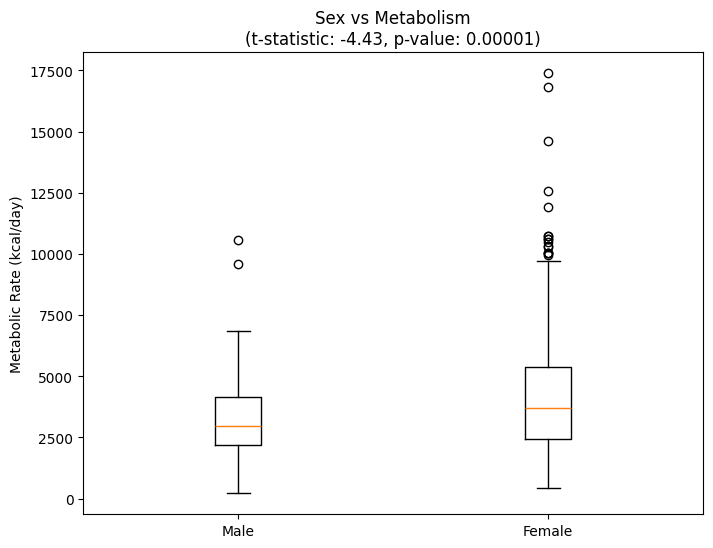

In [5]:
## Categorical variable
x = []
y = []
for user_ID, rate in user_MR:
    sex = user_data[user_data['ID'] == user_ID]['Sex'].values[0]
    x.append(sex)
    y.append(rate)

# run t-test
male_rates = [rate for user_ID, rate in user_MR if user_data[user_data['ID'] == user_ID]['Sex'].values[0] == 1 and not np.isnan(rate)]
female_rates = [rate for user_ID, rate in user_MR if user_data[user_data['ID'] == user_ID]['Sex'].values[0] == 0 and not np.isnan(rate)]
t_stat, p_val = stats.ttest_ind(male_rates, female_rates, nan_policy='omit')

# plot
plt.figure(figsize=(8, 6))
plt.boxplot([male_rates, female_rates], tick_labels=['Male', 'Female'])
plt.ylabel('Metabolic Rate (kcal/day)')
plt.title(f'Sex vs Metabolism\n(t-statistic: {t_stat:.2f}, p-value: {p_val:.5f})')
plt.show()

Finally, describe what you found in the report.  For each parameter, also try to provide a reasonable explanation for your findings.

**Step 5:** For the continuous parameter, report the correlation value and plot the regression line.

**Step 6:** For the categorical parameter, report the p-value.
